In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
from scipy.stats import ttest_ind
from scipy.stats import f as fdistribution
from Helpers.finalproject import *

In [2]:
with open("/Users/Haley/Desktop/murray-neuroscience-lab/Cleaned, updated files from Spring/binned_waveforms_metadata.pkl", "rb") as f:
    binned_waveforms = pickle.load(f)


Drop not labeled

In [20]:
# Drop waveforms with Group labeled as "not labeled" (robust to case/extra spaces)
before_n = len(binned_waveforms)

binned_waveforms = {
    key: value
    for key, value in binned_waveforms.items()
    if str(key[6]).strip().lower() not in {"not labeled", "not labelled"}
}

after_n = len(binned_waveforms)
print(f"Dropped {before_n - after_n} waveforms with Group='not labeled'.")
print(f"Remaining waveforms: {after_n}")

Dropped 2379 waveforms with Group='not labeled'.
Remaining waveforms: 18498


In [3]:

# --- DEBUG: what's actually in the pkl? ---
print(f"Total keys: {len(binned_waveforms)}")
groups_in_data = set()
cell_types_in_data = set()
signal_types_in_data = set()
freq_range = []

for key in binned_waveforms.keys():
    freq, signal_type, median, mean, cell_type, rin, group, cell = key
    groups_in_data.add(group)
    cell_types_in_data.add(cell_type)
    signal_types_in_data.add(signal_type)
    freq_range.append(freq)

print(f"Groups:      {groups_in_data}")
print(f"Cell Types:  {cell_types_in_data}")
print(f"Signal Types:{signal_types_in_data}")
print(f"Freq range:  {min(freq_range):.1f} – {max(freq_range):.1f} Hz")
print(f"\nSample key: {list(binned_waveforms.keys())[0]}")



Total keys: 20877
Groups:      {'Primary', 'Low Rin Secondary', 'High Rin Secondary', 'not labeled'}
Cell Types:  {'dVS', 'dSMN', 'iSMN', 'MiP', 'dRoP', 'nan', 'vRoP', 'iSMN (dorsal) muscle', 'CaP', 'vSMN'}
Signal Types:{'Inhibitory (Rs compensation)', 'Inhibitory', 'Excitatory', 'Excitatory (Rs compensation)'}
Freq range:  0.1 – 80.8 Hz

Sample key: (np.float64(30.98373353985868), 'Excitatory', np.float64(24.52), np.float64(24.97), 'vSMN', np.float64(287.0), 'Low Rin Secondary', '2012_08_01_cell1')


In [5]:
onewave = list(binned_waveforms.keys())[0]
binned_waveforms[onewave]

,Phase Bin,Current,Normalized Current,Phase
0,"(-0.501, -0.49]",-57.075497,0.799154,-0.4955
1,"(-0.49, -0.48]",-53.401943,0.844408,-0.4850
2,"(-0.48, -0.47]",-52.172108,0.859558,-0.4750
3,"(-0.47, -0.46]",-52.806850,0.851739,-0.4650
4,"(-0.46, -0.45]",-55.282589,0.821241,-0.4550
...,...,...,...,...
95,"(0.45, 0.46]",-50.029751,0.885949,0.4550
96,"(0.46, 0.47]",-52.448269,0.856156,0.4650
97,"(0.47, 0.48]",-50.670273,0.878059,0.4750
98,"(0.48, 0.49]",-48.263546,0.907707,0.4850


In [6]:
binned_waveforms[onewave]

,Phase Bin,Current,Normalized Current,Phase
0,"(-0.501, -0.49]",-57.075497,0.799154,-0.4955
1,"(-0.49, -0.48]",-53.401943,0.844408,-0.4850
2,"(-0.48, -0.47]",-52.172108,0.859558,-0.4750
3,"(-0.47, -0.46]",-52.806850,0.851739,-0.4650
4,"(-0.46, -0.45]",-55.282589,0.821241,-0.4550
...,...,...,...,...
95,"(0.45, 0.46]",-50.029751,0.885949,0.4550
96,"(0.46, 0.47]",-52.448269,0.856156,0.4650
97,"(0.47, 0.48]",-50.670273,0.878059,0.4750
98,"(0.48, 0.49]",-48.263546,0.907707,0.4850


flip excitatory signals


In [49]:
for wave in binned_waveforms.keys():
    freq, signal_type, median, mean, cell_type, rin, group, cell = wave
    if signal_type == "Excitatory (Rs compensation)" or signal_type == "Excitatory":
        binned_waveforms[wave] = binned_waveforms[wave].copy()
        binned_waveforms[wave]["Normalized Current"] = 1 - binned_waveforms[wave]["Normalized Current"]
        binned_waveforms[wave]["Current"] = -binned_waveforms[wave]["Current"]

In [ ]:
from collections import Counter

def get_freq_bin(freq):
    if 15 <= freq < 25:
        return "15–25"
    elif 25 <= freq < 35:
        return "25–35"
    elif 35 <= freq < 45:
        return "35–45"
    elif freq >= 45:
        return "45+"
    else:
        return None

def get_speed_bin(value, cutoff=35):
    return "fast" if value > cutoff else "slow"

def normalize_signal_type(s: str) -> str:
    s_low = s.strip().lower()
    if s_low.startswith("excitatory"):
        return "Excitatory"
    if s_low.startswith("inhibitory"):
        return "Inhibitory"
    if "cell-attached" in s_low:
        return None
    return s  

key_counts = Counter()
for freq, signal_type, median, mean in binned_waveforms.keys():
    norm_type = normalize_signal_type(signal_type)
    freq_bin = get_freq_bin(freq)
    if norm_type is None:  # skip unwanted signals
        continue
    if freq_bin is None:  # skip unwanted signals
        continue
    grouped_key = (
        freq_bin,
        norm_type,
        get_speed_bin(median)   # or mean
    )
    key_counts[grouped_key] += 1



freq, signal_type, median, mean, cell_type, rin, group, cell

In [5]:
one_wave = list(binned_waveforms.keys())[0]
testdf = binned_waveforms[one_wave].copy()
phase = testdf['Phase'].values
norm_currents = testdf['Normalized Current'].values
peak_idx = np.argmax(norm_currents)
peak_phase = phase[peak_idx]
peak_amplitude = norm_currents[peak_idx]
slope, intercept = np.polyfit(phase, norm_currents, 1)

In [22]:
features_df = extract_excitatory_features(binned_waveforms)

# Keep categorical metadata as clean strings
for col in ['Cell Type', 'Group', 'Cell']:
    if col in features_df.columns:
        features_df[col] = features_df[col].astype('string').str.strip()

# Ensure numerical stats columns remain numeric
for col in ['Peak Gain', 'Peak Phase', 'Peak Amplitude', 'Rin', 'Freq', 'Median Spiking', 'Mean Spiking']:
    if col in features_df.columns:
        features_df[col] = pd.to_numeric(features_df[col], errors='coerce')

summary_across_celltype = aggregate_features(features_df)

In [23]:

# --- DEBUG: inspect features_df ---
print("Shape:", features_df.shape)
print("\nFreq Bin value counts (including NaN/None):")
print(features_df['Freq Bin'].value_counts(dropna=False))
print("\nGroup value counts:")
print(features_df['Group'].value_counts(dropna=False))
print("\nCell Type value counts:")
print(features_df['Cell Type'].value_counts(dropna=False))
print("\nRin group value counts:")
if 'Rin group' in features_df.columns:
    print(features_df['Rin group'].value_counts(dropna=False))
print("\nSample rows:")
features_df.head(10)


Shape: (11565, 11)

Freq Bin value counts (including NaN/None):
Freq Bin
20-30    5844
None     3176
30-40    2545
Name: count, dtype: int64

Group value counts:
Group
Primary               7039
High Rin Secondary    3162
Low Rin Secondary     1364
Name: count, dtype: Int64

Cell Type value counts:
Cell Type
MiP     2728
vSMN    1746
iSMN    1721
CaP     1659
vRoP    1605
dRoP    1047
dSMN     766
dVS      293
Name: count, dtype: Int64

Rin group value counts:

Sample rows:


,Cell,Cell Type,Rin,Group,Median Spiking,Mean Spiking,Freq,Freq Bin,Peak Gain,Peak Phase,Peak Amplitude
0,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,30.983734,30-40,-0.024259,0.005,0.879934
1,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,26.861863,20-30,-0.111277,-0.095,0.847007
2,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,24.394706,20-30,0.138601,-0.025,0.841503
3,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,27.170221,20-30,0.205467,-0.025,0.919930
4,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,27.290714,20-30,-0.103795,-0.045,0.935301
5,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,25.926886,20-30,-0.418451,-0.175,0.911115
6,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,22.992470,20-30,-0.065576,0.025,0.811733
7,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,0.801073,None,0.087278,0.285,0.658949
8,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,0.808128,None,-0.272634,-0.445,0.687279
9,2012_08_01_cell1,vSMN,287.0,Low Rin Secondary,24.52,24.97,28.399006,20-30,0.155035,-0.045,0.943844


In [50]:
feature_cols = ["Peak Gain","Peak Phase","Peak Amplitude"]

In [51]:
feature_cols = ["Peak Gain","Peak Phase","Peak Amplitude"]
hotttest_results_between = compute_hotellings_tests_grouped(
    features_df, 
    feature_cols,
    compare_col='Group', 
    freq_col='Freq Bin'
)
hotttest_results_between
# hotttest_results_between.to_csv("hott_Brin",index=False)

,Freq Bin,Group_1,Group_2,T2_stat,F_stat,p_value
0,30-40,Low Rin Secondary,Primary,42.482903,14.146414,4.025071e-09
1,30-40,Low Rin Secondary,High Rin Secondary,164.538566,54.752194,1.110223e-16
2,30-40,Primary,High Rin Secondary,186.306751,62.039234,1.110223e-16
3,20-30,Low Rin Secondary,Primary,20.611802,6.867376,1.302358e-04
4,20-30,Low Rin Secondary,High Rin Secondary,312.056845,103.912861,1.110223e-16
5,20-30,Primary,High Rin Secondary,897.475146,299.048800,1.110223e-16


In [52]:
hotttest_results = compute_hotellings_tests(
    features_df, 
    feature_cols,
    group_col='Group', 
    compare_col='Cell Type', 
    freq_col='Freq Bin'
)
hotttest_results
# hotttest_results.to_csv("hott_NrinBcell",index=False)

,Freq Bin,Group,Cell Type_1,Cell Type_2,T2_stat,F_stat,p_value
0,30-40,Low Rin Secondary,vSMN,dSMN,189.294487,62.844246,1.110223e-16
1,30-40,Low Rin Secondary,vSMN,dVS,262.538377,86.628825,1.110223e-16
2,30-40,Low Rin Secondary,dSMN,dVS,94.723546,31.431967,1.110223e-16
3,30-40,Primary,MiP,vRoP,322.505906,107.303442,1.110223e-16
4,30-40,Primary,MiP,CaP,62.326310,20.704531,9.253709e-13
5,30-40,Primary,MiP,dRoP,17.096016,5.681481,7.619646e-04
6,30-40,Primary,vRoP,CaP,436.105305,144.958369,1.110223e-16
7,30-40,Primary,vRoP,dRoP,150.121107,49.913040,1.110223e-16
8,30-40,Primary,CaP,dRoP,156.774486,51.896514,1.110223e-16
9,30-40,High Rin Secondary,iSMN,vSMN,24.069355,7.996150,3.122410e-05


In [53]:
def get_freq_bin(freq):
    if 15 <= freq < 25:
        return "15–25"
    elif 25 <= freq < 35:
        return "25–35"
    elif 35 <= freq < 45:
        return "35–45"
    elif freq >= 45:
        return "45+"
    else:
        return None

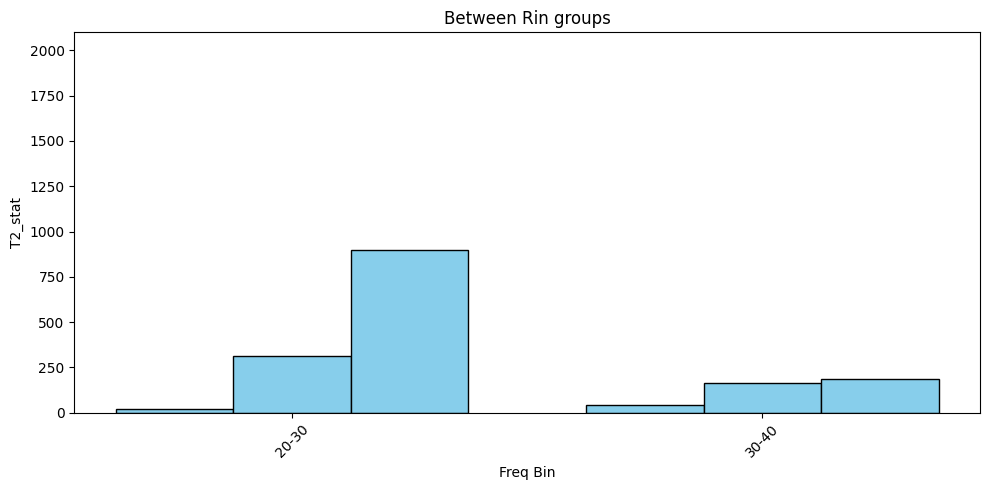

In [54]:
results_df=hotttest_results_between
stat_col = "T2_stat"
freq_col="Freq Bin"
figsize=(10, 5)
bar_width=0.2

freq_bins = sorted(results_df[freq_col].dropna().unique(), key=str)

subset = results_df
    
# Count how many bars per bin to offset properly
counts_per_bin = {fb: len(subset[subset[freq_col] == fb]) for fb in freq_bins}
# print(counts_per_bin)
max_count = max(counts_per_bin.values())
# print(max_count)
plt.figure(figsize=figsize)
x_ticks = []
x_labels = []

idx = 0
for i, fb in enumerate(freq_bins):
    bin_subset = subset[subset[freq_col] == fb]
    # print(bin_subset)
    stats = bin_subset[stat_col].values
    # print(stats)
    x = np.arange(len(stats)) * bar_width + i * (max_count + 1) * bar_width
    # print(x)
    plt.bar(x, stats, width=bar_width, color='skyblue', edgecolor='black')

    # Save tick positions and labels
    center_x = x.mean() if len(x) > 0 else i
    x_ticks.append(center_x)
    x_labels.append(fb)

    idx += 1
plt.ylim([0, 2100])

plt.xticks(ticks=x_ticks, labels=x_labels, rotation=45)
plt.xlabel(freq_col)
plt.ylabel(stat_col)
plt.title("Between Rin groups")
plt.tight_layout()
plt.show()
    

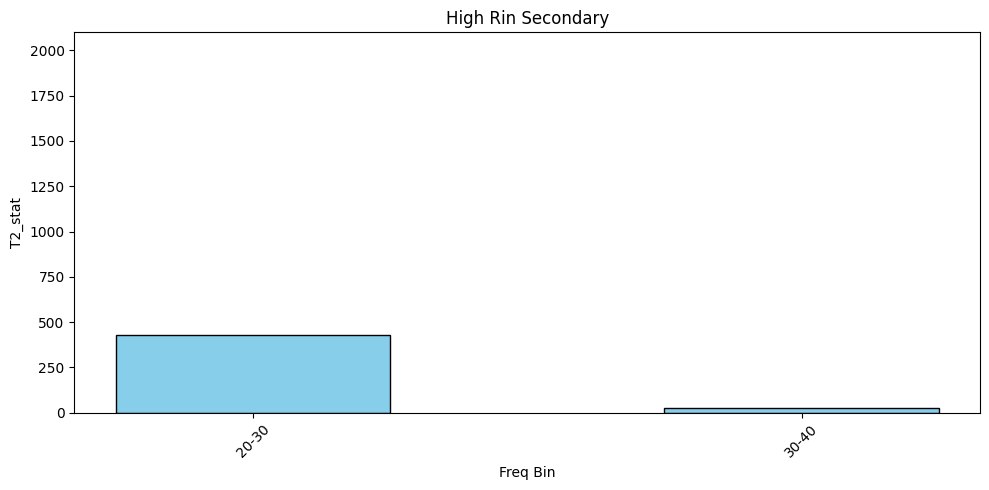

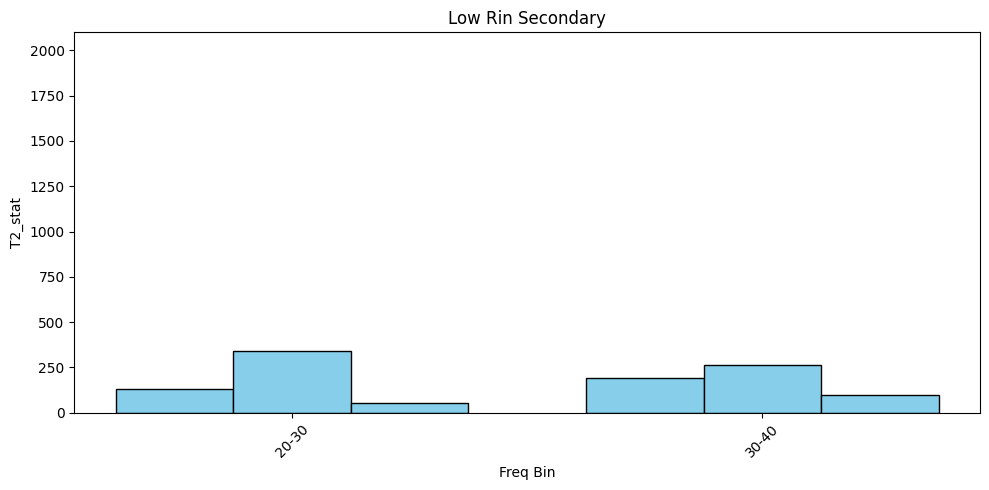

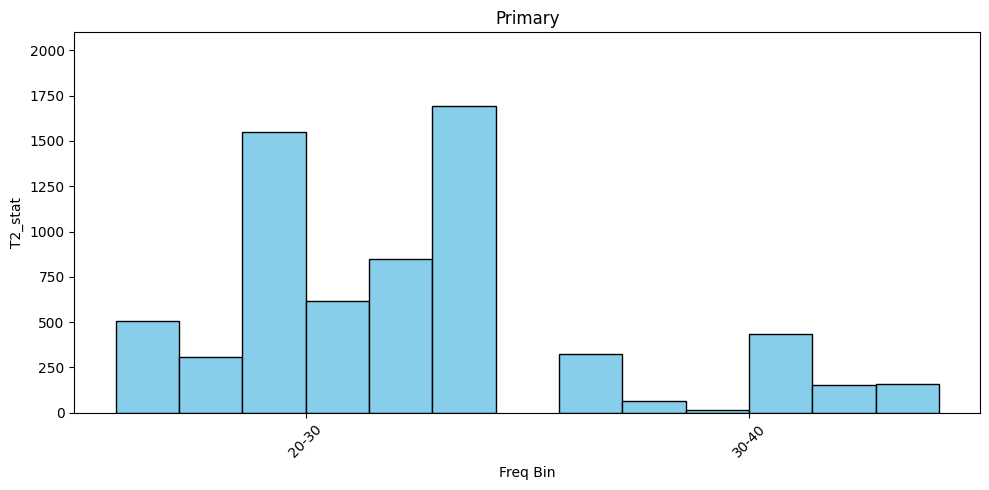

In [55]:
group_col='Group'

results_df = hotttest_results
freq_col='Freq Bin'
stat_col='T2_stat'
title_prefix="Stat Distribution"
figsize=(10, 5)
bar_width=0.2
title_prefix="Stat Distribution"

unique_groups = sorted(results_df[group_col].dropna().unique())
freq_bins = sorted(results_df[freq_col].dropna().unique(), key=str)

for group in unique_groups:
    subset = results_df[results_df[group_col] == group]
    
    # Count how many bars per bin to offset properly
    counts_per_bin = {fb: len(subset[subset[freq_col] == fb]) for fb in freq_bins}
    # print(counts_per_bin)
    max_count = max(counts_per_bin.values())
    # print(max_count)
    plt.figure(figsize=figsize)
    x_ticks = []
    x_labels = []

    idx = 0
    for i, fb in enumerate(freq_bins):
        bin_subset = subset[subset[freq_col] == fb]
        # print(bin_subset)
        stats = bin_subset[stat_col].values
        # print(stats)
        x = np.arange(len(stats)) * bar_width + i * (max_count + 1) * bar_width
        # print(x)
        plt.bar(x, stats, width=bar_width, color='skyblue', edgecolor='black')

        # Save tick positions and labels
        center_x = x.mean() if len(x) > 0 else i
        x_ticks.append(center_x)
        x_labels.append(fb)

        idx += 1
    plt.ylim([0, 2100])

    plt.xticks(ticks=x_ticks, labels=x_labels, rotation=45)
    plt.xlabel(freq_col)
    plt.ylabel(stat_col)
    plt.title(f"{group}")
    plt.tight_layout()
    plt.show()

In [56]:
primary = features_df[features_df["Group"]=="primary"]
Hsecondary = features_df[features_df["Group"]=="High Rin Secondary"]
Lsecondary = features_df[features_df["Group"]=="Low Rin Secondary "]

In [57]:
def bonferroni_correction(df, alpha=0.05):
    """
    Apply Bonferroni correction to p-values in the DataFrame.
    
    Parameters:
        df: pd.DataFrame
            Must contain a 'p_value' column.
        alpha: float
            Desired significance level.
    
    Returns:
        df with new columns 'p_value_corrected' and 'significant' (bool)
    """
    n_tests = len(df)
    corrected_alpha = alpha / n_tests
    df = df.copy()
    df['p_value_corrected'] = df['p_value'] * n_tests
    df['p_value_corrected'] = df['p_value_corrected'].clip(upper=1.0)  # max 1
    df['significant'] = df['p_value_corrected'] < alpha
    return df, corrected_alpha

In [58]:
def ttester(feature):
    ttest_results_celltype1 = compute_ttests(
        primary, 
        feature, 
        group_col='Freq Bin', 
        compare_col='Cell Type', 
        freq_col='Freq Bin'
    )
    ttest_results_celltype2 = compute_ttests(
        Lsecondary, 
        feature, 
        group_col='Freq Bin', 
        compare_col='Cell Type', 
        freq_col='Freq Bin'
    )
    ttest_results_celltype3 = compute_ttests(
        Hsecondary, 
        feature, 
        group_col='Freq Bin', 
        compare_col='Cell Type', 
        freq_col='Freq Bin'
    )
    ttest_results= pd.concat([ttest_results_celltype1,ttest_results_celltype2,ttest_results_celltype3],ignore_index=False)

    corrected_df, corrected_alph = bonferroni_correction(ttest_results)
    return corrected_df, corrected_alph
# corrected_df.to_csv("phasetst")
corrected_df,corrected_alph = ttester("Peak Gain")

In [59]:
def num_significant(corrected_df):
    print("primary slow:",sum(corrected_df.iloc[0:5,6])/6)
    print("primary fast:",sum(corrected_df.iloc[5:12,6])/6)
    print("low rin secondary slow:",sum(corrected_df.iloc[12:15,6])/3)
    print("low rin secondary fast:",sum(corrected_df.iloc[15:18,6])/3)
    print("high rin slow:",sum(corrected_df.iloc[18:19,6]))
    print("high rin fast:",sum(corrected_df.iloc[19:,6]))

num_significant(corrected_df)

primary slow: 0.3333333333333333
primary fast: 0.0
low rin secondary slow: 0.0
low rin secondary fast: 0.0
high rin slow: 0
high rin fast: 0


# Plotting waveforms

In [60]:
from collections import Counter

key_counts_all = Counter()

for freq, signal_type, median, mean, cell_type, rin, group, cell in binned_waveforms.keys():
    freq_bin = get_freq_bin(freq)
    cell_type_gen = group_iSMN(cell_type)
    signal_type_gen = group_EI(signal_type)
    grouped_key = (freq_bin, signal_type_gen, cell_type_gen, group)
    key_counts_all[grouped_key] += 1

freq_bins = set()
signal_types = set()
cell_types = set()
group_types = set()

for freq_bin, signal_type, cell_type, group_name in key_counts_all.keys():
    if freq_bin is None:
        continue
    freq_bins.add(freq_bin)
    signal_types.add(signal_type)
    cell_types.add(cell_type)
    group_types.add(group_name)

In [61]:
def average_waveforms_for_key(counter_key, binned):
    '''
    Function that takes a counter key like ('20-30', 'Excitatory', 'iSMN', 'primary')
    Returns a DataFrame with mean and SEM of normalized current for that key
    '''

    freq_bin, signal_type, cell_type, group_name = counter_key

    dfs = []
    for key in binned.keys():
        freq, st, median, mean, ct, rn, waveform_group, cell = key

        if (
            get_freq_bin(freq) == freq_bin
            and group_iSMN(ct) == group_iSMN(cell_type)
            and group_EI(st) == group_EI(signal_type)
            and waveform_group == group_name
        ):
            df = binned[key].copy()
            dfs.append(df)

    if not dfs:
        print(f"No matching waveforms found for {counter_key}")
        return None

    combined = pd.concat(dfs, ignore_index=True)
    grouped = combined.groupby('Phase', observed=False)['Normalized Current']
    averaged = grouped.mean().reset_index(name='Normalized Current')
    sem = grouped.sem().reset_index(name='SEM')
    sem['SEM'] = sem['SEM'].astype(float)
    result = pd.merge(averaged, sem, on='Phase')
    return result

/var/folders/mw/pz4gm95j6zb7syl48vm11wrw0000gn/T/ipykernel_20907/3665373458.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(cell_types))


No matching waveforms found for ('15–25', 'Excitatory', 'dVS', 'Primary')
No matching waveforms found for ('15–25', 'Excitatory', 'dSMN', 'Primary')
No matching waveforms found for ('15–25', 'Excitatory', 'iSMN', 'Primary')
No matching waveforms found for ('15–25', 'Excitatory', 'vSMN', 'Primary')
No matching waveforms found for ('15–25', 'Excitatory', 'dVS', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'dSMN', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'iSMN', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'MiP', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'dRoP', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'vRoP', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'CaP', 'Low Rin Secondary')
No matching waveforms found for ('15–25', 'Excitatory', 'dVS', 'High Rin Secondary')
No matching waveforms fo

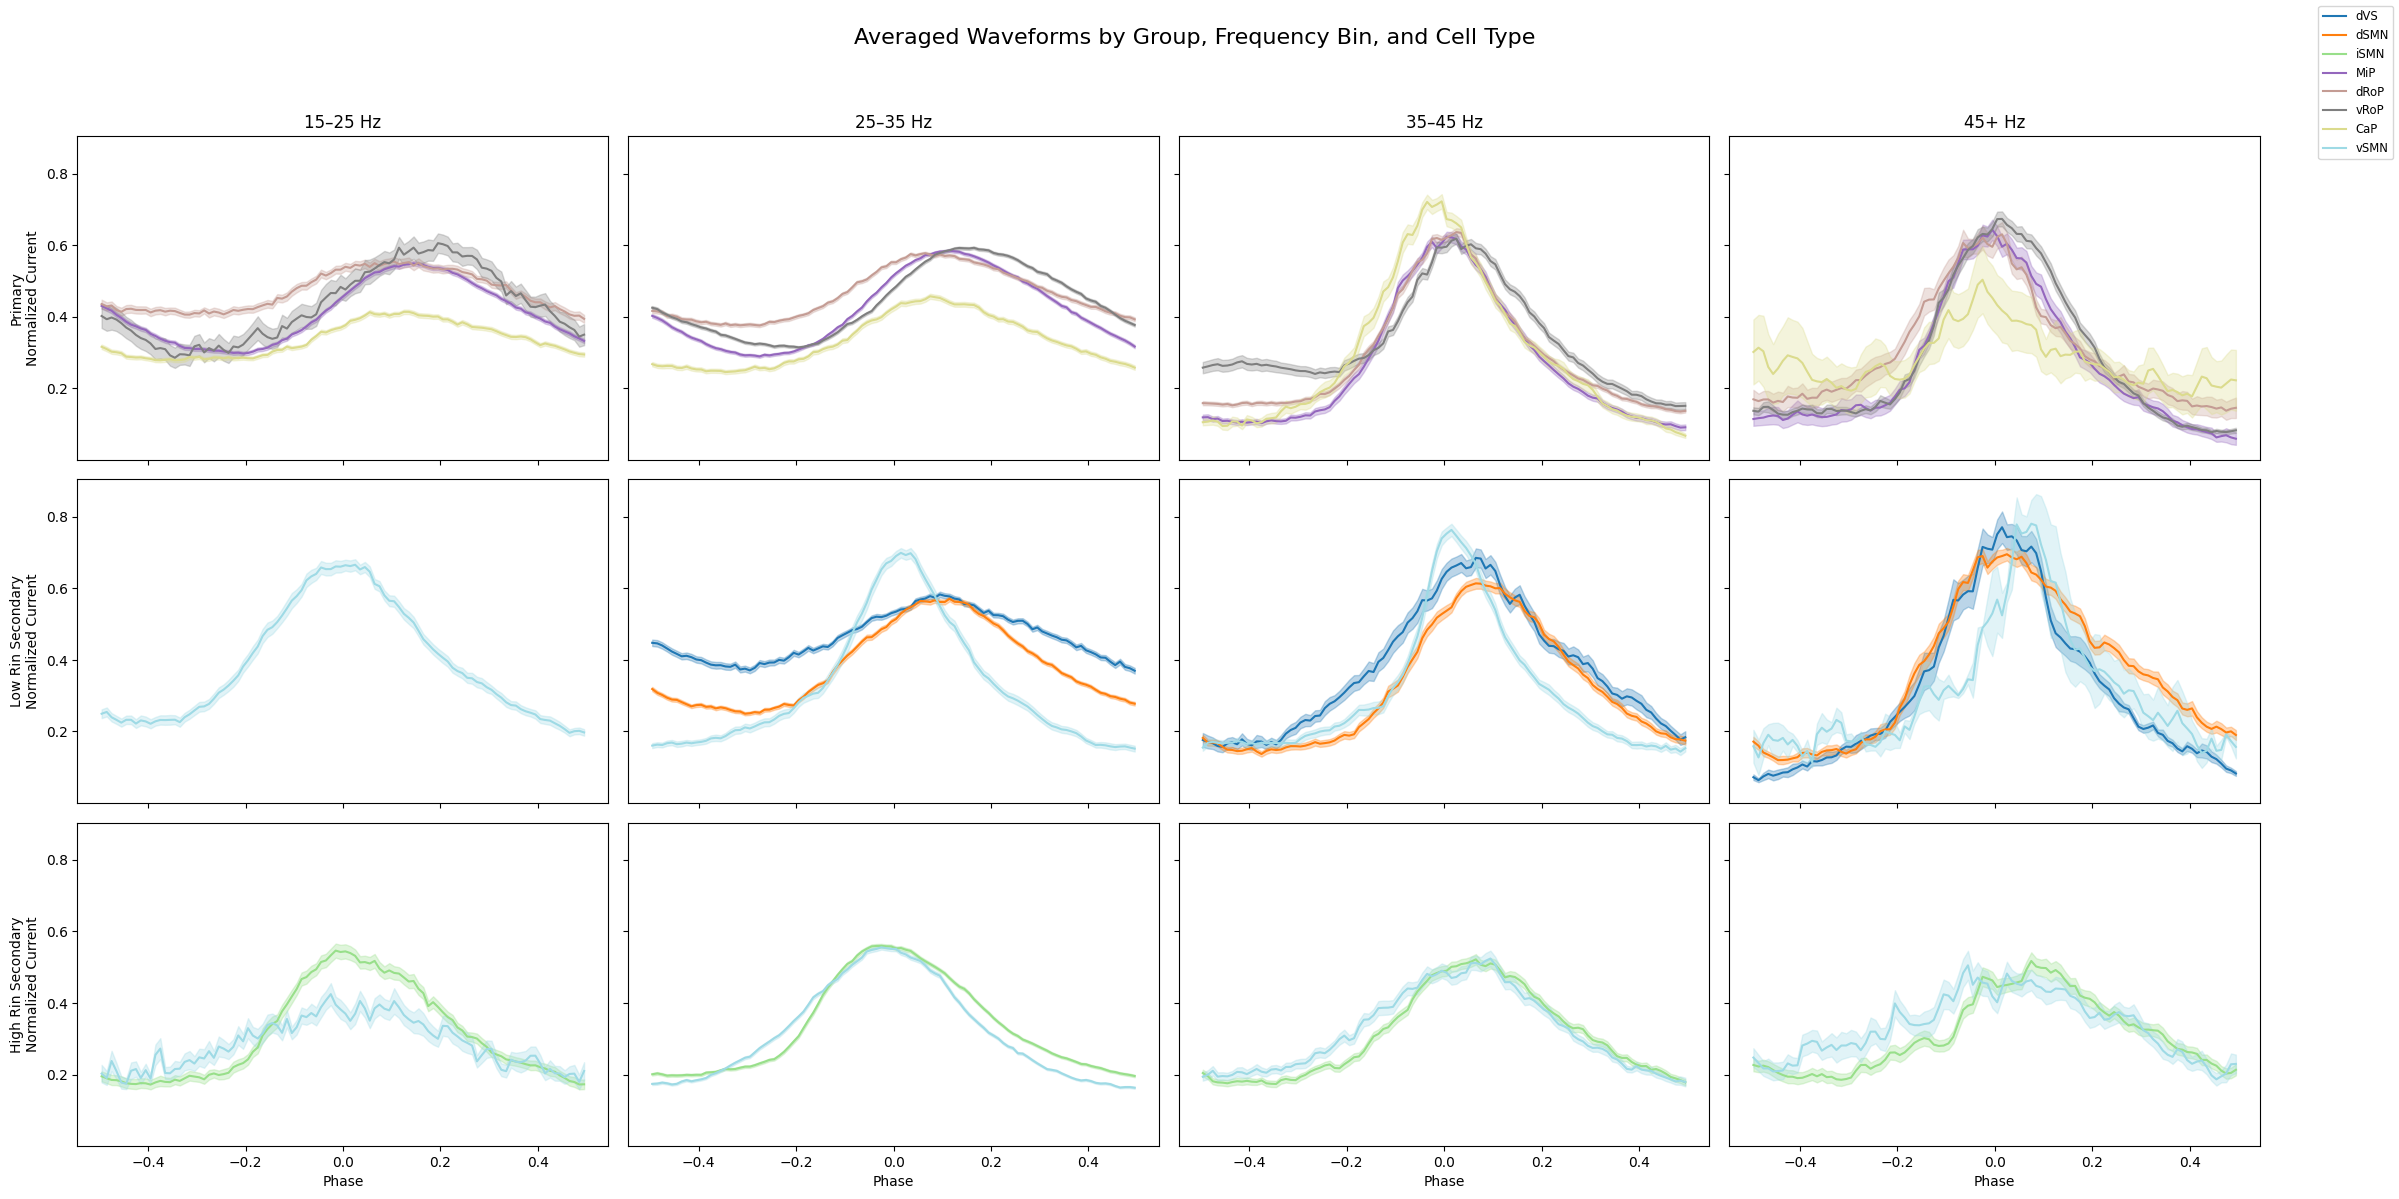

In [66]:
signal_types = ["Excitatory"]

def freq_bin_sort_key(freq_label):
    s = str(freq_label).strip()
    if "–" in s:
        return float(s.split("–")[0])
    if "-" in s:
        return float(s.split("-")[0])
    if s.endswith("+"):
        return float(s[:-1])
    return float("inf")

freq_bins_sorted = sorted(freq_bins, key=freq_bin_sort_key)

cmap = cm.get_cmap('tab20', len(cell_types))
cell_type_colors = {ctype: cmap(i) for i, ctype in enumerate(cell_types)}

fig, axes = plt.subplots(len(group_types), len(freq_bins_sorted), figsize=(24, 12), sharex=True, sharey=True)

for j, freq_bin in enumerate(freq_bins_sorted):
    for i, group_name in enumerate(group_types):
        ax = axes[i, j]

        for signal_type in signal_types:
            for cell_type in cell_types:
                counter_key = (freq_bin, signal_type, cell_type, group_name)
                avg_waveform_df = average_waveforms_for_key(counter_key, binned_waveforms)
                if avg_waveform_df is None or avg_waveform_df.empty:
                    continue

                label = f"{cell_type} ({signal_type})"
                ax.plot(avg_waveform_df['Phase'], avg_waveform_df['Normalized Current'],
                        label=label, color=cell_type_colors[cell_type])
                ax.fill_between(avg_waveform_df['Phase'],
                                avg_waveform_df['Normalized Current'] - avg_waveform_df['SEM'],
                                avg_waveform_df['Normalized Current'] + avg_waveform_df['SEM'],
                                color=cell_type_colors[cell_type], alpha=0.3)

        if i == 0:
            ax.set_title(f"{freq_bin} Hz")
        if j == 0:
            ax.set_ylabel(f"{group_name}\nNormalized Current")
        if i == len(group_types) - 1:
            ax.set_xlabel("Phase")

handles, labels = [], []
for ctype in cell_types:
    handles.append(plt.Line2D([0], [0], color=cell_type_colors[ctype]))
    labels.append(ctype)
fig.legend(handles, labels, loc='upper right', fontsize='small')

fig.suptitle("Averaged Waveforms by Group, Frequency Bin, and Cell Type", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

/var/folders/mw/pz4gm95j6zb7syl48vm11wrw0000gn/T/ipykernel_20907/322190744.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(cell_types))


No matching waveforms found for ('45+', 'Excitatory', 'dVS', 'Primary')
No matching waveforms found for ('45+', 'Excitatory', 'dVS', 'High Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'dSMN', 'Primary')
No matching waveforms found for ('45+', 'Excitatory', 'dSMN', 'High Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'iSMN', 'Primary')
No matching waveforms found for ('45+', 'Excitatory', 'iSMN', 'Low Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'MiP', 'Low Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'MiP', 'High Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'dRoP', 'Low Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'dRoP', 'High Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'vRoP', 'Low Rin Secondary')
No matching waveforms found for ('45+', 'Excitatory', 'vRoP', 'High Rin Secondary')
No matching waveforms found for (

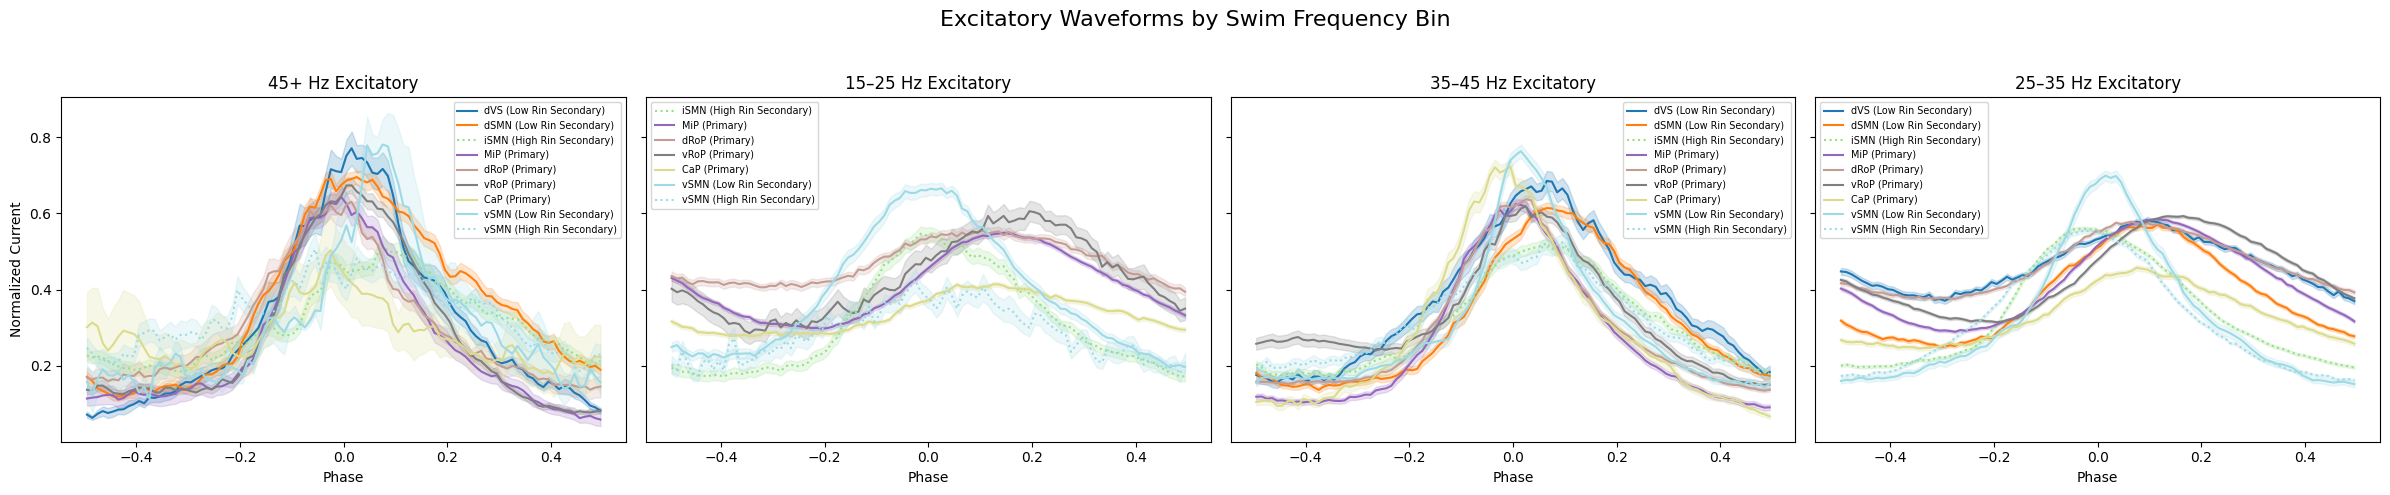

In [67]:
signal_type = "Excitatory"
line_styles = {'primary': 'solid', 'Low Rin Secondary ': 'dashed', 'High Rin Secondary': 'dotted'}

cmap = cm.get_cmap('tab20', len(cell_types))
cell_type_colors = {ctype: cmap(i) for i, ctype in enumerate(cell_types)}

fig, axes = plt.subplots(1, len(freq_bins), figsize=(6 * len(freq_bins), 5), sharey=True)

if len(freq_bins) == 1:
    axes = [axes]

for idx, freq_bin in enumerate(freq_bins):
    ax = axes[idx]

    for cell_type in cell_types:
        for group_name in group_types:
            counter_key = (freq_bin, signal_type, cell_type, group_name)
            avg_waveform_df = average_waveforms_for_key(counter_key, binned_waveforms)
            if avg_waveform_df is None or avg_waveform_df.empty:
                continue

            label = f"{cell_type} ({group_name})"
            ax.plot(avg_waveform_df['Phase'], avg_waveform_df['Normalized Current'],
                    label=label,
                    color=cell_type_colors[cell_type],
                    linestyle=line_styles.get(group_name, 'solid'),
                    linewidth=1.5)

            ax.fill_between(avg_waveform_df['Phase'],
                            avg_waveform_df['Normalized Current'] - avg_waveform_df['SEM'],
                            avg_waveform_df['Normalized Current'] + avg_waveform_df['SEM'],
                            color=cell_type_colors[cell_type], alpha=0.2)

    ax.set_title(f"{freq_bin} Hz Excitatory")
    ax.set_xlabel("Phase")
    if idx == 0:
        ax.set_ylabel("Normalized Current")
    ax.legend(fontsize='x-small', loc='best')

fig.suptitle("Excitatory Waveforms by Swim Frequency Bin", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()